# 06 · Climate vs fuel: they are not the same objective

Airlines optimise fuel burn; the planet cares about **total climate forcing**. Aviation's non-CO₂ effects — persistent contrails and altitude-amplified NOx ozone chemistry — can rival or exceed its CO₂ warming, and they depend strongly on *where* you fly. So the minimum-fuel cruise altitude is **not** generally the minimum-climate one.

> ⚠️ **This notebook uses a clearly-labelled pedagogical climate proxy** (`_learning_utils.climate_proxy`). Real non-CO₂ forcing depends on the local atmosphere (temperature, ice super-saturation), not a single altitude curve. PhlyGreen also has a rigorous `climateimpact`/`welltowake` path (see `examples/14`); here we keep the climate model transparent so the *trade-off mechanism* is visible.

In [1]:
# --- environment setup (educational tutorials) ---------------------------------
# These notebooks teach concepts *through* PhlyGreen. They use the real design API where
# it exists and small, clearly-labelled pedagogical proxies where it does not.
import warnings
warnings.filterwarnings("ignore")     # keep the solver's internal chatter out of the output
import numpy as np
import matplotlib.pyplot as plt

from _learning_utils import add_examples_to_path
add_examples_to_path()                # puts trunk/examples on sys.path (no absolute paths)

import PhlyGreen as pg
from PhlyGreen import postprocess as pp

from common import traditional_config
from _learning_utils import safe_design, set_cruise_altitude, climate_proxy, nonco2_multiplier

alts = np.arange(5000, 9600, 500)        # cruise altitude sweep [m]
print('cruise altitudes [m]:', list(alts))

cruise altitudes [m]: [np.int64(5000), np.int64(5500), np.int64(6000), np.int64(6500), np.int64(7000), np.int64(7500), np.int64(8000), np.int64(8500), np.int64(9000), np.int64(9500)]


## Sweep cruise altitude: fuel burn from PhlyGreen

We move the whole cruise (and the matching climb top / descent start) to each altitude and resize the aircraft, recording block fuel. For a turboprop over this range there is an **interior fuel optimum**: too low is draggy, too high costs climb energy and a less efficient cruise.

In [2]:
fuel = []
for h in alts:
    cfg = traditional_config(); set_cruise_altitude(cfg, float(h))
    res, ok, note = safe_design(cfg)
    fuel.append(res.block_fuel if ok else np.nan)
fuel = np.array(fuel)
i_fuel = int(np.nanargmin(fuel))
print(f'minimum-fuel cruise altitude ~ {alts[i_fuel]:.0f} m  ({fuel[i_fuel]:,.0f} kg block fuel)')

minimum-fuel cruise altitude ~ 6000 m  (1,982 kg block fuel)


## Add the climate proxy

The proxy combines CO₂ from the fuel with an **altitude-dependent non-CO₂ multiplier** (contrails + NOx grow with altitude). Same fuel burn at a higher altitude ⇒ more climate impact.

In [3]:
climate = np.array([climate_proxy(f, h) for f, h in zip(fuel, alts)])
i_clim = int(np.nanargmin(climate))
print(f'minimum-climate cruise altitude ~ {alts[i_clim]:.0f} m')
print(f'non-CO2 multiplier ranges {nonco2_multiplier(alts.min()):.2f} -> {nonco2_multiplier(alts.max()):.2f}')

minimum-climate cruise altitude ~ 5000 m
non-CO2 multiplier ranges 1.25 -> 2.20


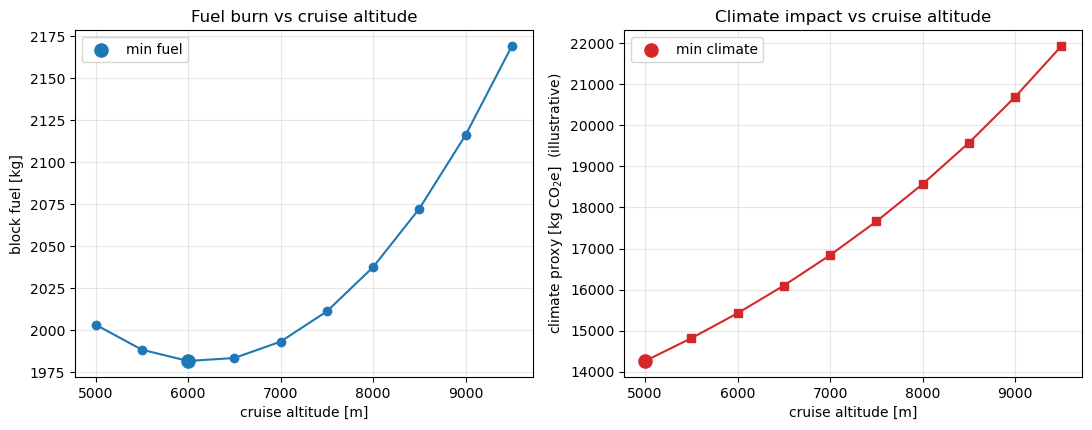

In [4]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
axL.plot(alts, fuel, 'o-', color='tab:blue')
axL.scatter([alts[i_fuel]], [fuel[i_fuel]], color='tab:blue', s=90, zorder=5, label='min fuel')
axL.set_xlabel('cruise altitude [m]'); axL.set_ylabel('block fuel [kg]')
axL.set_title('Fuel burn vs cruise altitude'); axL.grid(alpha=0.3); axL.legend()
axR.plot(alts, climate, 's-', color='tab:red')
axR.scatter([alts[i_clim]], [climate[i_clim]], color='tab:red', s=90, zorder=5, label='min climate')
axR.set_xlabel('cruise altitude [m]'); axR.set_ylabel('climate proxy [kg CO$_2$e]  (illustrative)')
axR.set_title('Climate impact vs cruise altitude'); axR.grid(alpha=0.3); axR.legend()
plt.show()

## The trade-off, as a Pareto plot

Put fuel on one axis and climate on the other. If the two optima coincided there would be a single best point; instead the minimum-fuel and minimum-climate altitudes **differ**, and the points between them form a trade-off front.

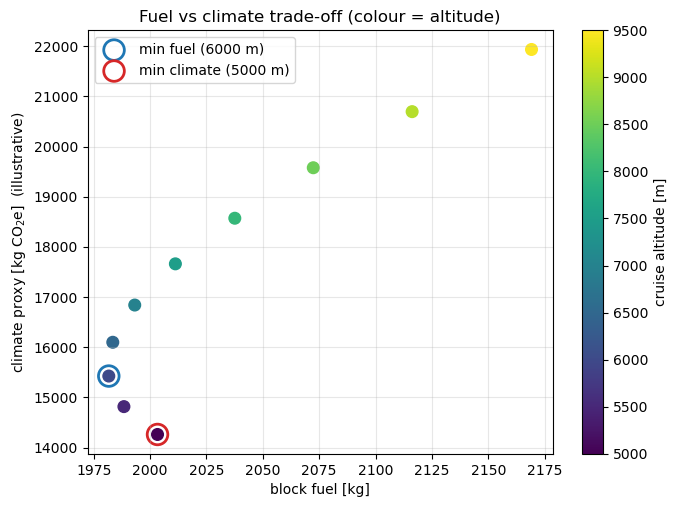

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sc = ax.scatter(fuel, climate, c=alts, cmap='viridis', s=70)
ax.scatter([fuel[i_fuel]], [climate[i_fuel]], edgecolor='tab:blue', facecolor='none',
           s=220, linewidth=2, label=f'min fuel ({alts[i_fuel]:.0f} m)')
ax.scatter([fuel[i_clim]], [climate[i_clim]], edgecolor='tab:red', facecolor='none',
           s=220, linewidth=2, label=f'min climate ({alts[i_clim]:.0f} m)')
cb = fig.colorbar(sc, ax=ax); cb.set_label('cruise altitude [m]')
ax.set_xlabel('block fuel [kg]'); ax.set_ylabel('climate proxy [kg CO$_2$e]  (illustrative)')
ax.set_title('Fuel vs climate trade-off (colour = altitude)')
ax.grid(alpha=0.3); ax.legend()
plt.show()

Flying lower than the fuel-optimal altitude burns a little more fuel but avoids the non-CO₂ penalty — a *net climate win* an airline chasing fuel cost would never pick. The size of this gap is exactly what current contrail-avoidance research is about.

## Key takeaways

1. **Minimum fuel ≠ minimum climate.** Non-CO₂ effects depend on altitude, so the two objectives generally disagree.
2. Optimising on **CO₂ alone** (or fuel alone) can *increase* total warming by ignoring contrails and NOx.
3. A credible climate assessment needs the **atmospheric state along the route**, not just the fuel burnt — which is why this proxy is only a teaching device.

## Questions for students

1. Why can reducing fuel burn fail to minimise total climate impact?
2. What is the danger of using CO₂ (or fuel) as the *sole* objective?
3. What additional information (atmospheric, operational) would a *rigorous* climate assessment need that this proxy lacks?

## Suggested modifications

- Change `nonco2_multiplier`'s `base`/`top` in `_learning_utils.py` — how strong must the non-CO₂ effect be before the two optima separate noticeably?
- Replace the proxy with PhlyGreen's `climateimpact.ATR()` (see `examples/14`) and compare the altitude trend.
- Add a contrail 'band' (non-zero only between, say, 8–10 km) instead of a monotonic curve and re-examine the Pareto front.
- Sweep cruise Mach as a second routing variable.

---
*These tutorials are educational. Where the full PhlyGreen capability is not exposed (formal constraint feasibility, non-CO₂ climate weighting) the notebook uses a simplified, clearly-labelled proxy — read the comments before trusting any number.*